In [1]:
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

--2026-10-06 07:08:13--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.1’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.07s   

2026-10-06 07:08:14 (9.12 MB/s) - ‘car_fuel_efficiency_2026.csv.1’ saved [635180/635180]



In [9]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 51.2 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 52.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 48.3 MB/s  0:00:00
Using cached pyparsing-3.3.3-py3-none-any.whl (126 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("car_fuel_efficiency_2026.csv")
display(df.head())
print("Rows and Columns:", df.shape)

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


Rows and Columns: (10000, 11)


In [4]:
columns = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
    "fuel_efficiency_mpg",
]

df = df[columns].copy()
display(df.head())

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


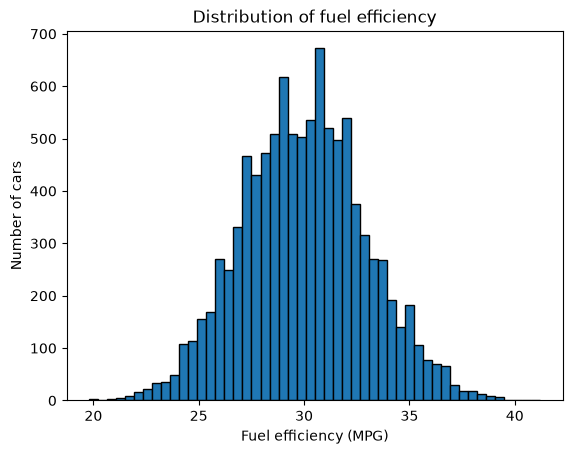

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64


In [5]:
plt.hist(df["fuel_efficiency_mpg"], bins=50, edgecolor="black")
plt.xlabel("Fuel efficiency (MPG)")
plt.ylabel("Number of cars")
plt.title("Distribution of fuel efficiency")
plt.show()

print(df["fuel_efficiency_mpg"].describe())

In [6]:
print(df.isnull().sum())

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64


In [7]:
median_horsepower = df["horsepower"].median()

print("Median horsepower:", median_horsepower)

Median horsepower: 254.0


In [8]:
def split_data(df, seed):
    n = len(df)

    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)

    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].copy()

    df_val = df.iloc[
        idx[n_train:n_train + n_val]
    ].copy()

    df_test = df.iloc[
        idx[n_train + n_val:]
    ].copy()

    return df_train, df_val, df_test

In [9]:
df_train, df_val, df_test = split_data(df, seed=42)

print("Training rows:", len(df_train))
print("Validation rows:", len(df_val))
print("Test rows:", len(df_test))

Training rows: 6000
Validation rows: 2000
Test rows: 2000


In [10]:
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
]

target = "fuel_efficiency_mpg"

y_train = df_train[target].to_numpy()
y_val = df_val[target].to_numpy()

In [11]:
def prepare_X(data, fill_value):
    return data[features].fillna(fill_value).to_numpy()

In [12]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)

    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [14]:
def rmse(y, y_pred):
    error = y - y_pred
    mse = np.mean(error ** 2)

    return np.sqrt(mse)

In [15]:
X_train_zero = prepare_X(df_train, fill_value=0)
X_val_zero = prepare_X(df_val, fill_value=0)

w0, w = train_linear_regression(X_train_zero, y_train)

y_pred_zero = w0 + X_val_zero.dot(w)

score_zero = rmse(y_val, y_pred_zero)

print("Zero replacement RMSE:", round(score_zero, 3))

Zero replacement RMSE: 2.205


In [16]:
mean_horsepower = df_train["horsepower"].mean()

print("Training mean horsepower:", mean_horsepower)

Training mean horsepower: 254.46338337605272


In [17]:
X_train_mean = prepare_X(df_train, fill_value=mean_horsepower)
X_val_mean = prepare_X(df_val, fill_value=mean_horsepower)

w0, w = train_linear_regression(X_train_mean, y_train)

y_pred_mean = w0 + X_val_mean.dot(w)

score_mean = rmse(y_val, y_pred_mean)

print("Mean replacement RMSE:", round(score_mean, 3))

Mean replacement RMSE: 2.202


In [18]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)

    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [19]:
X_train = prepare_X(df_train, fill_value=0)
X_val = prepare_X(df_val, fill_value=0)

r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

for r in r_values:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    print(f"r = {r:6} | RMSE = {round(score, 4):.4f}")

r =      0 | RMSE = 2.2053
r =   0.01 | RMSE = 2.2058
r =    0.1 | RMSE = 2.2241
r =      1 | RMSE = 2.3492
r =      5 | RMSE = 2.4094
r =     10 | RMSE = 2.4195
r =    100 | RMSE = 2.4292


In [20]:
scores = []

for seed in range(10):
    train_part, val_part, test_part = split_data(df, seed=seed)

    X_train = prepare_X(train_part, fill_value=0)
    X_val = prepare_X(val_part, fill_value=0)

    y_train = train_part[target].to_numpy()
    y_val = val_part[target].to_numpy()

    w0, w = train_linear_regression(X_train, y_train)

    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    scores.append(score)

    print(f"Seed {seed}: RMSE = {score:.6f}")

std = np.std(scores)

print("\nStandard deviation:", round(std, 3))

Seed 0: RMSE = 2.239204
Seed 1: RMSE = 2.202113
Seed 2: RMSE = 2.163420
Seed 3: RMSE = 2.204359
Seed 4: RMSE = 2.201880
Seed 5: RMSE = 2.245785
Seed 6: RMSE = 2.269721
Seed 7: RMSE = 2.190795
Seed 8: RMSE = 2.216611
Seed 9: RMSE = 2.207037

Standard deviation: 0.029


In [21]:
df_train, df_val, df_test = split_data(df, seed=9)

df_full_train = pd.concat(
    [df_train, df_val],
    ignore_index=True,
)

print("Combined training rows:", len(df_full_train))
print("Test rows:", len(df_test))

Combined training rows: 8000
Test rows: 2000


In [22]:
X_full_train = prepare_X(df_full_train, fill_value=0)
y_full_train = df_full_train[target].to_numpy()

X_test = prepare_X(df_test, fill_value=0)
y_test = df_test[target].to_numpy()

w0, w = train_linear_regression_reg(
    X_full_train,
    y_full_train,
    r=0.001,
)

y_pred = w0 + X_test.dot(w)

test_score = rmse(y_test, y_pred)

print("Test RMSE:", round(test_score, 3))

Test RMSE: 2.236
